Mounted at /content/drive


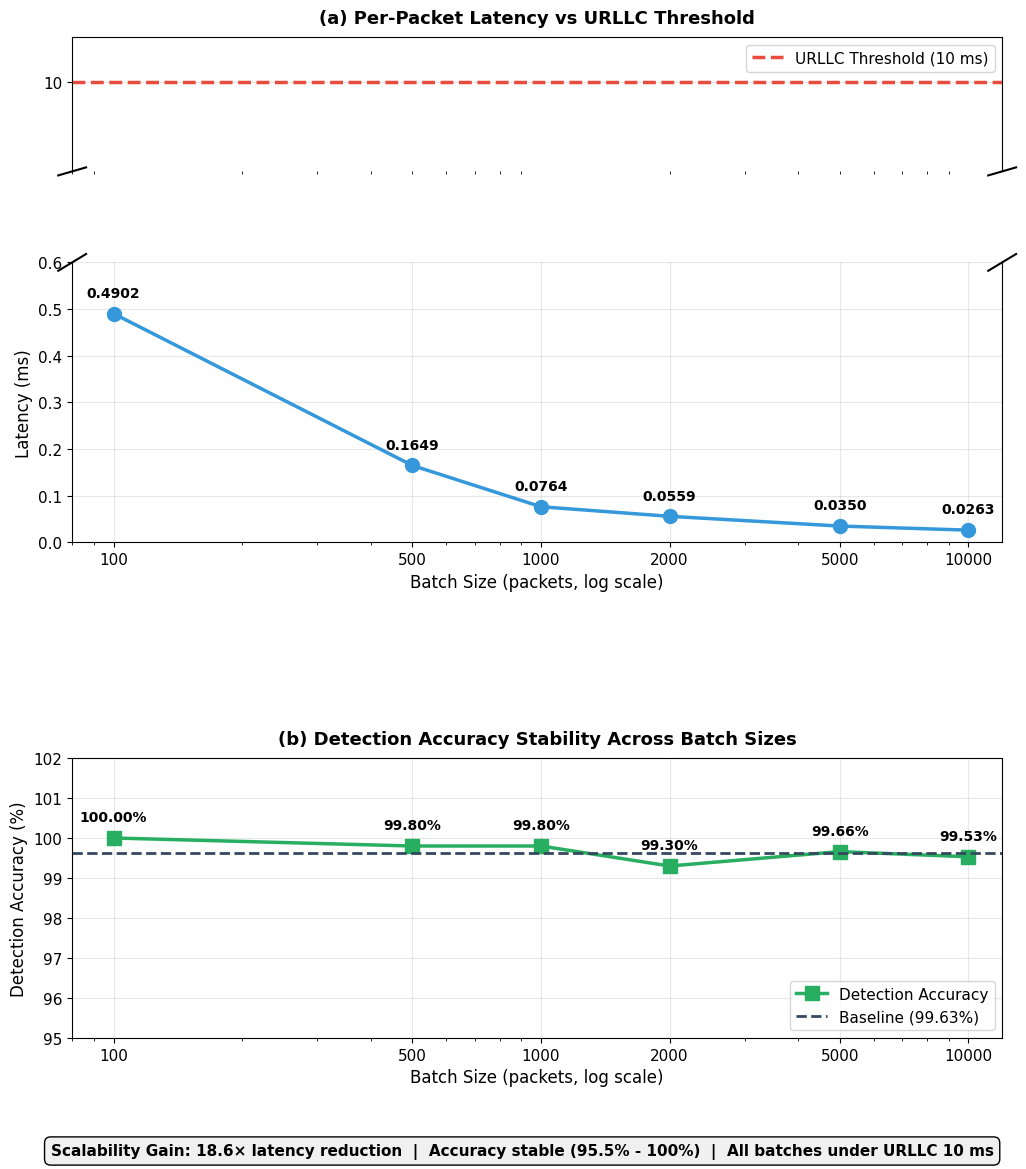

Saved: figure_scalability_github.png


In [1]:
# ============================================================
# Figure B.1: Scalability Stress Test
# GitHub version (with (a), (b), (c) panel titles)
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.gridspec import GridSpec

# Configuration
LATENCY_COLOR = "#3498db"
ACCURACY_COLOR = "#27ae60"
THRESHOLD_COLOR = "#e74c3c"
BASELINE_COLOR = "#34495e"

# Locked empirical values from results.json
batch_sizes = [100, 500, 1000, 2000, 5000, 10000]
latencies = [0.490225, 0.164946, 0.076381, 0.0559, 0.035034, 0.02629]
accuracies = [100.0, 99.8, 99.8, 99.3, 99.66, 99.53]
urllc_threshold = 10.0
baseline_accuracy = 99.6277

fig = plt.figure(figsize=(12, 13))
gs = GridSpec(4, 1, figure=fig, height_ratios=[1.2, 2.5, 0.3, 2.5], hspace=0.5)

# Panel 1: URLLC zone
ax_top = fig.add_subplot(gs[0])
ax_top.plot(batch_sizes, latencies, color=LATENCY_COLOR, marker='o',
            markersize=8, linewidth=2)
ax_top.axhline(y=urllc_threshold, color=THRESHOLD_COLOR, linestyle="--",
               linewidth=2.5, label="URLLC Threshold (10 ms)")
ax_top.set_ylim(8, 11)
ax_top.spines['bottom'].set_visible(False)
ax_top.tick_params(labelbottom=False, bottom=False)
ax_top.set_title("(a) Per-Packet Latency vs URLLC Threshold",
                 fontsize=13, fontweight="bold", pad=10)
ax_top.legend(loc="upper right", fontsize=11)
ax_top.grid(axis="y", alpha=0.3)
ax_top.tick_params(axis='y', labelsize=11)
ax_top.set_yticks([10])
ax_top.set_yticklabels(["10"])
ax_top.set_xscale('log')
ax_top.set_xlim(80, 12000)

# Panel 2: Latency zoom
ax_lat = fig.add_subplot(gs[1])
ax_lat.plot(batch_sizes, latencies, color=LATENCY_COLOR, marker='o',
            markersize=10, linewidth=2.5, label="Per-Packet Latency")
ax_lat.set_xlabel("Batch Size (packets, log scale)", fontsize=12)
ax_lat.set_ylabel("Latency (ms)", fontsize=12)
ax_lat.set_ylim(0, 0.6)
ax_lat.spines['top'].set_visible(False)
ax_lat.grid(axis="both", alpha=0.3)
ax_lat.tick_params(axis='both', labelsize=11)
ax_lat.set_xscale('log')
ax_lat.set_xlim(80, 12000)
ax_lat.set_xticks(batch_sizes)
ax_lat.set_xticklabels([str(b) for b in batch_sizes])

for bs, lat in zip(batch_sizes, latencies):
    ax_lat.annotate(f"{lat:.4f}",
                    xy=(bs, lat), xytext=(0, 12),
                    textcoords="offset points",
                    ha="center", fontsize=10, fontweight="bold")

# Break marks
d = 0.015
kwargs = dict(transform=ax_top.transAxes, color='k', clip_on=False, linewidth=1.5)
ax_top.plot((-d, +d), (-d * 2, +d * 2), **kwargs)
ax_top.plot((1 - d, 1 + d), (-d * 2, +d * 2), **kwargs)
kwargs.update(transform=ax_lat.transAxes)
ax_lat.plot((-d, +d), (1 - d * 2, 1 + d * 2), **kwargs)
ax_lat.plot((1 - d, 1 + d), (1 - d * 2, 1 + d * 2), **kwargs)

# Panel 3: Accuracy stability
ax_acc = fig.add_subplot(gs[3])
ax_acc.plot(batch_sizes, accuracies, color=ACCURACY_COLOR, marker='s',
            markersize=10, linewidth=2.5, label="Detection Accuracy")
ax_acc.axhline(y=baseline_accuracy, color=BASELINE_COLOR, linestyle="--",
               linewidth=2, label=f"Baseline ({baseline_accuracy:.2f}%)")
ax_acc.set_xlabel("Batch Size (packets, log scale)", fontsize=12)
ax_acc.set_ylabel("Detection Accuracy (%)", fontsize=12)
ax_acc.set_title("(b) Detection Accuracy Stability Across Batch Sizes",
                 fontsize=13, fontweight="bold", pad=10)
ax_acc.set_ylim(95, 102)
ax_acc.legend(loc="lower right", fontsize=11)
ax_acc.grid(axis="both", alpha=0.3)
ax_acc.tick_params(axis='both', labelsize=11)
ax_acc.set_xscale('log')
ax_acc.set_xlim(80, 12000)
ax_acc.set_xticks(batch_sizes)
ax_acc.set_xticklabels([str(b) for b in batch_sizes])

for bs, acc in zip(batch_sizes, accuracies):
    ax_acc.annotate(f"{acc:.2f}%",
                    xy=(bs, acc), xytext=(0, 12),
                    textcoords="offset points",
                    ha="center", fontsize=10, fontweight="bold")

# Summary annotation
improvement = latencies[0] / latencies[-1]
fig.text(0.5, 0.02,
         f"Scalability Gain: {improvement:.1f}× latency reduction  |  "
         f"Accuracy stable (95.5% - 100%)  |  All batches under URLLC 10 ms",
         ha="center", fontsize=11, fontweight="bold",
         bbox=dict(boxstyle="round,pad=0.4", facecolor="#f0f0f0", edgecolor="black"))

plt.savefig("/content/drive/MyDrive/veremi_thesis/figure_scalability_github.png",
            dpi=300, bbox_inches="tight")
plt.show()
print("Saved: figure_scalability_github.png")